In [1]:
import os

# GitHub 저장소 클론
# 이 명령어는 '080289'라는 폴더를 현재 디렉토리에 생성하고 저장소 내용을 다운로드합니다.
!git clone https://github.com/gilbutITbook/080289.git

# 클론된 디렉토리 구조 확인 (선택 사항)
# !ls -R 080289/chap05/data/catanddog

fatal: destination path '080289' already exists and is not an empty directory.


# **5.3 전이학습**
**5.3.1 특성추출 기법**
* OpenCV  = Open Source Computer Vision Library의 약어

In [2]:
!pip install opencv-python

In [3]:
#라이브러리 호출
import numpy as np
import os
import time
import copy
import glob
import cv2 #앞에 설치함 OpenCV 라이브러리
import shutil

import torch
import torchvision #컴퓨터 비전 용도의 패키지
import torchvision.transforms as transforms #데이터 전처리를 위해 사용되는 패캐지
import torchvision.models as models #다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [4]:
data_path = '080289/chap05/data/catanddog/train'

transform = transforms.Compose(
    [
        transforms.Resize([256,256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform = transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = 32,
    num_workers = 8,
    shuffle=True
)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


1. torchvision.transform: 이미지 데이터를 변환해 모델의 입력으로 사용할 수 있게 변환

**파라미터**
* Resize: 이미지의 크기를 조정,
* RandomResizedCrop: 이미지를 랜덤한 크기 및 비율로 자름
> Resize가 합성곱층을 통과하기 위해 이미지 크기 조정하는 전처리 과정이라면, RandomResizedCrop은 데이터 확장 용도로 사용됨. 이미지를 랜덤한 비율로 자른 후 데이터 크기 조정

* RandomHorizontalFlip: 이미지를 랜덤하게 수평으로 뒤집음
* ToTensor: 이미지 데이터를 텐서로 변환

2. datasets.ImageFolder: 데이터로더가 데이터를 불러올 대산과 방법을 정의

**파라미터**
* 첫번째 파라미터: 불러올 데이터가 위치한 경로
* transform: 이미지 데이터에 대한 전처리

3. 데이터로더는 데이터를 불러오는 부분으로 앞에 정의한 ImageFolder(train_dataset)을 데이터로더에 할당.
이때 batch_size 지정.shuffle 여부도 설정

**파라미터**
* 첫번째 파라미터: 데이터셋 지정
* batch_size : 한번에 불러올 데이터양 지정
* num_workers: 데이터를 불러올 때 하위 프로세스를 몇 개 사용할지 설정.이때, 너무 많으면 오류 발생 or 메모리 부족 현상
* shuffle: 데이터를 무작위로 섞을지 지정.


**RandomResizedCrop**


In [2]:
!pip install torch torchvision torchaudio

In [3]:
!pip install mxnet
!pip install --user mxnet

In [10]:
!ls -l '080289/chap05/data/cat.jpg'

-rw-r--r-- 1 root root 216293 Mar 28 12:56 080289/chap05/data/cat.jpg


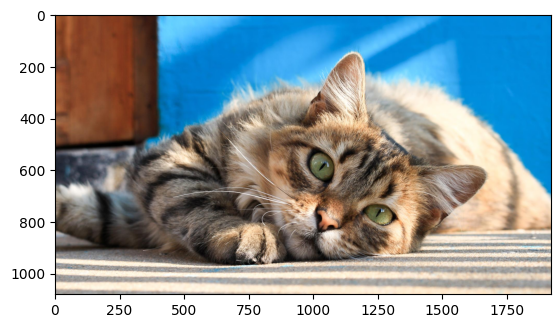

In [11]:
import numpy as np
# Monkey patch for compatibility with older libraries expecting np.bool
if not hasattr(np, 'bool'):
    np.bool = bool

import matplotlib.pyplot as plt
import mxnet as mx
from mxnet.gluon.data.vision import transforms

example_image = mx.image.imread("080289/chap05/data/cat.jpg")

plt.imshow(example_image.asnumpy())

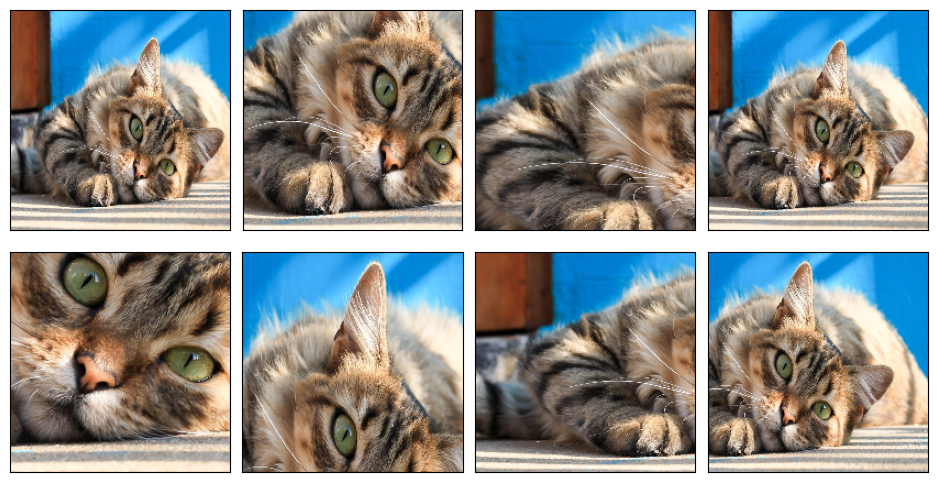

In [16]:
def show_images(imgs, num_rows, num_cols, scale=2):
  aspect_ratio = imgs[0].shape[0]/imgs[0].shape[1]
  figsize = (num_cols * scale, num_rows*scale*aspect_ratio)
  _, axes = plt.subplots(num_rows, num_cols, figsize = figsize)
  for i in  range(num_rows):
    for j in range(num_cols):
      axes[i][j].imshow(imgs[i*num_cols + j].asnumpy())
      axes[i][j].axes.get_xaxis().set_visible(False)
      axes[i][j].axes.get_yaxis().set_visible(False)
  plt.subplots_adjust(hspace=0.1, wspace=0) # This should apply to the whole figure
  return axes # This should be outside the for loops

def apply(img, aug, num_rows=2, num_cols=4, scale=3):
  Y = [aug(img) for _ in range(num_rows * num_cols)]
  show_images(Y, num_rows, num_cols, scale)

shape_aug = transforms.RandomResizedCrop(size = (200,200),
                                         scale = (0.1, 1),
                                         ratio = (0.5,2))
apply(example_image, shape_aug)

**파라미터**
* size: 출력할 크기를 200*200으로 조정
* scale: 면적 비율을 0.1 ~ 1(10~100%) 범위 내에서 무작위로 자름
* ratio: 면적의 너비와 높이 비율을 0.5~2 범위 내에서 무작위로 조절

-----------------------------------

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


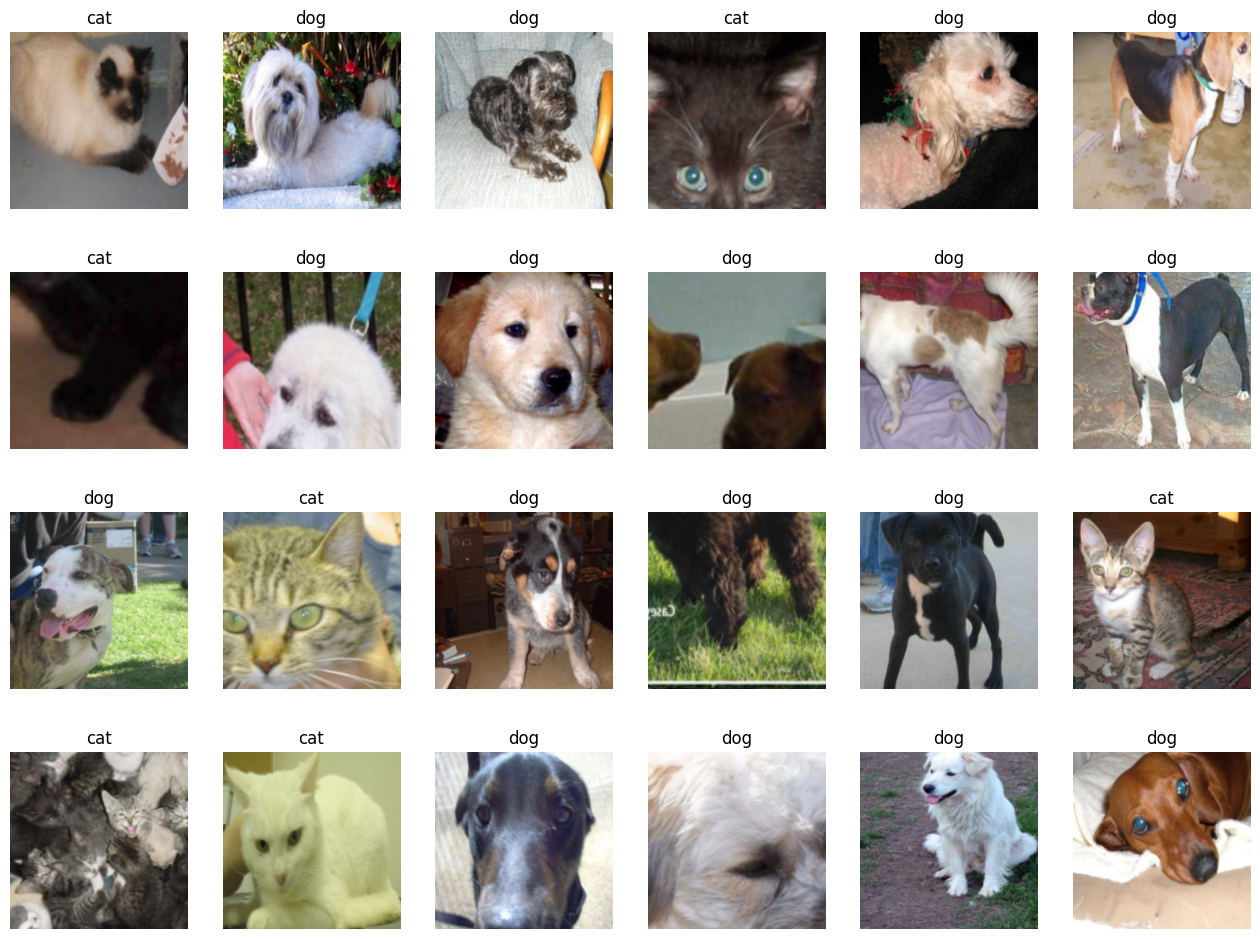

In [5]:
import numpy as np # Add import for numpy

samples, labels = next(iter(train_loader)) # Fix: Use next() function
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize = (16,24))
for i in range(24):
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()]) # Fix: set_title instead of set_titls
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

1. 반복자
* iter() : 전달된 데이터의 반복자를 꺼내 반환
* next(): 그 반복자가 다음에 출력해야할 요소를 반환
* 앞의 코드에서 반복자는 train_loader => samples와 labels의 값을 순차적으로 꺼내서 저장

2. np.transpose : 행과 열을 바꿔 행렬의 차원 바꿈. 행렬의 내적 연산 때문
* print(samples.shape)로 확인한 데이터의 형태 =>  torch.Size([32,3,224,224]) -> 이상태 그대로 사용하면 invalid shape 오류 발생
* 따라서, np.transpose(samples[i].numpy(), (1,2,0))을 사용해서 (224,224,3)과 같은 형태로 변환

In [6]:
exam = np.arange(24).reshape(2,3,4)
exam

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [7]:
np.transpose(exam,(2,1,0))

array([[[ 0, 12],
        [ 4, 16],
        [ 8, 20]],

       [[ 1, 13],
        [ 5, 17],
        [ 9, 21]],

       [[ 2, 14],
        [ 6, 18],
        [10, 22]],

       [[ 3, 15],
        [ 7, 19],
        [11, 23]]])

In [8]:
#사전 훈련된 모델 내려받기
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 105MB/s]


**ResNet18**
: 50개의 계층으로 구성된 합성곱 신경망.
imageNet 데이터베이스의 100만 개가 넘는 영상을 이용해 훈련된 신경망으로 전이 학습에 사용되도록 사전 훈련된 모델을 제공

**사전 훈련된 모델**


```
import torchvision.models as models
resnet18 = models.resnet18()
alexnet = models.alexnet()
vgg16 = models.vgg16()
squeezenet = models.squeezenet1_0()
densenet = models.densenet161()
inception = models.inception_v3()
googlenet = models.googlenet()
shufflenet= models.shufflenet_v2_x1_0()
mobilenet_v2 = models.mobilenet_v2()
mobilenet_v3_large = models.mobilenet_v3_large()
moblienet_v3_small = models.mobilenet_v3_small()
resnext50_32x4d = models.resnext50_32x4d()
wide_resnet50_2 = models.wide_resnet50_2()
mnasnet = models.mnasnet1_0()
```



```
import torchvision.models as models
resnet18 = models.resnet18(pretrained=True)
alexnet = models.alexnet(pretrained=True)
vgg16 = models.vgg16(pretrained=True)
squeezenet = models.squeezenet1_0(pretrained=True)
densenet = models.densenet161(pretrained=True)
inception = models.inception_v3(pretrained=True)
googlenet = models.googlenet(pretrained=True)
shufflenet= models.shufflenet_v2_x1_0(pretrained=True)
mobilenet_v2 = models.mobilenet_v2(pretrained=True)
mobilenet_v3_large = models.mobilenet_v3_large(pretrained=True)
moblienet_v3_small = models.mobilenet_v3_small(pretrained=True)
resnext50_32x4d = models.resnext50_32x4d(pretrained=True)
wide_resnet50_2 = models.wide_resnet50_2(pretrained=True)
mnasnet = models.mnasnet1_0(pretrained=True)
```



In [33]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad=False

set_parameter_requires_grad(resnet18)

1. 역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음. 모델의 일부(합성곱층, 풀링)를 고정하고 나머지를 학습하고자할 때 requires_grad = False로 설정
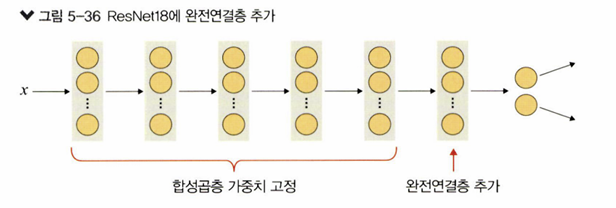

In [34]:
resnet18.fc = nn.Linear(512, 2)

In [35]:
for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[ 0.0131,  0.0077, -0.0076,  ..., -0.0322,  0.0429,  0.0333],
        [ 0.0379,  0.0130, -0.0155,  ..., -0.0222, -0.0287,  0.0044]])
fc.bias tensor([-0.0140, -0.0370])


In [36]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
  param.requires_grad = False

model.fc = torch.nn.Linear(512,2)
for param in model.fc.parameters():
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [37]:
from torch.nn.modules import loss
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time()
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs,labels)
      _, preds = torch.max(outputs, 1)
      loss.backward()
      optimizer.step()

      running_loss += loss.item() * inputs.size(0)
      running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss /len(dataloaders.dataset)
    epoch_acc = running_corrects.double() / len(dataloaders.dataset)

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())

    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('080289/chap05/data/catanddog/',
                                                '{0:0=2d}.pth'.format(epoch)))
    print()

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed //60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history



In [38]:
#파라미터 학습 결과를 옵티마이저에 전달
params_to_update =[]
for name, param in resnet18.named_parameters():
  if param.requires_grad ==True:
    params_to_update.append(param)
    print("\t", name)

optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loss: 0.6318 Acc: 0.6234

Epoch 1/12
----------
Loss: 0.4093 Acc: 0.8286

Epoch 2/12
----------
Loss: 0.2672 Acc: 0.9169

Epoch 3/12
----------
Loss: 0.2269 Acc: 0.9247

Epoch 4/12
----------
Loss: 0.1947 Acc: 0.9429

Epoch 5/12
----------
Loss: 0.1823 Acc: 0.9429

Epoch 6/12
----------
Loss: 0.1860 Acc: 0.9377

Epoch 7/12
----------
Loss: 0.1773 Acc: 0.9325

Epoch 8/12
----------
Loss: 0.1706 Acc: 0.9455

Epoch 9/12
----------
Loss: 0.1545 Acc: 0.9506

Epoch 10/12
----------
Loss: 0.1529 Acc: 0.9532

Epoch 11/12
----------
Loss: 0.1538 Acc: 0.9429

Epoch 12/12
----------
Loss: 0.1434 Acc: 0.9455

Training complete in 8m 6s
Best Acc: 0.953247


In [40]:
test_path = '080289/chap05/data/catanddog/test'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)
test_dataset = torchvision.datasets.ImageFolder(
    root = test_path,
    transform = transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = 32,
    num_workers = 1,
    shuffle = True
)

print(len(test_dataset))

98


In [41]:
def eval_model(model, dataloaders, device):
  since =time.time()
  acc_history = []
  best_acc = 0.0

  # Corrected the glob pattern to match the new save directory
  saved_models = glob.glob('080289/chap05/data/catanddog/' + '*.pth')
  saved_models.sort()
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad():
        outputs = model(inputs)

      _, preds = torch.max(outputs.data,1)
      preds[preds >= 0.5] = 1
      preds[preds < 0.5] = 0
      running_corrects += preds.eq(labels.cpu()).int().sum()

    epoch_acc = running_corrects.double() /len(dataloaders.dataset)
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc
      acc_history.append(epoch_acc.item())
      print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed //60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))

  return acc_history

1. glob : 현재 디렉터리에서 원하는 파일들만 추출해 가져올 때 사용. 즉, 경로에서 pth 확장자를 갖는 파일을 가져오라는 의미. .pth라는 확장자를 갖는 파일은 훈련 데이터로 모델을 훈련시킬 때 생성된 파일

2. torch.max: 주어진 텐서 배열의 최댓값이 들어 있는 index를 반환하는 함수

3. preds.eq(labels) : preds 배열과 labels가 일치하는지 검사하는 용도로 사용

In [42]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['080289/chap05/data/catanddog/00.pth', '080289/chap05/data/catanddog/01.pth', '080289/chap05/data/catanddog/02.pth', '080289/chap05/data/catanddog/03.pth', '080289/chap05/data/catanddog/04.pth', '080289/chap05/data/catanddog/05.pth', '080289/chap05/data/catanddog/06.pth', '080289/chap05/data/catanddog/07.pth', '080289/chap05/data/catanddog/08.pth', '080289/chap05/data/catanddog/09.pth', '080289/chap05/data/catanddog/10.pth', '080289/chap05/data/catanddog/11.pth', '080289/chap05/data/catanddog/12.pth']
Loading model 080289/chap05/data/catanddog/00.pth
Acc: 0.7245

Validation complete in 0m 8s
Best Acc: 0.724490
Loading model 080289/chap05/data/catanddog/01.pth
Acc: 0.9082

Validation complete in 0m 18s
Best Acc: 0.908163
Loading model 080289/chap05/data/catanddog/02.pth
Acc: 0.9286

Validation complete in 0m 27s
Best Acc: 0.928571
Loading model 080289/chap05/data/catanddog/03.pth
Acc: 0.9490

Validation complete in 0m 36s
Best Acc: 0.948980
Loading model 080289/chap05/data/

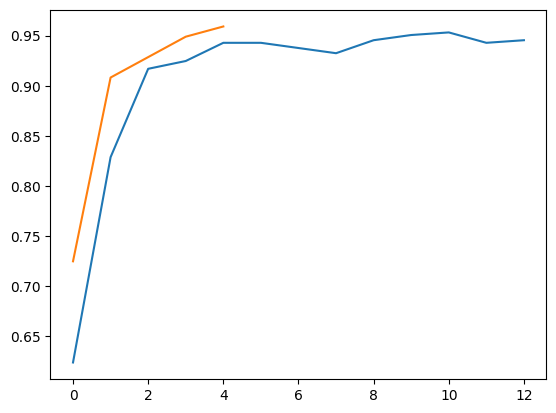

In [43]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

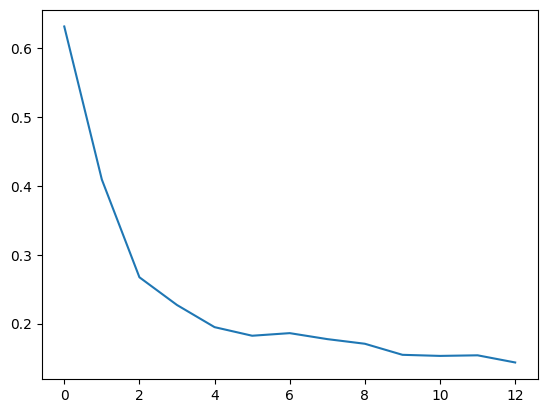

In [44]:
plt.plot(train_loss_hist)
plt.show()

In [45]:
def im_convert(tensor):
  image = tensor.clone().detach().numpy()
  image = image.transpose(1,2,0)
  image = image*(np.array((0.5, 0.5, 0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip(0,1)
  return image

1. tensor.clone(): 기존 텐서의 내용을 복사한 텐서를 생성하겠다는 의미, detach(): 기존 텐서에서 기울기가 전파되지 않는 텐서, tensor.clone().deatch()는 기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지는 않겠다는 의미
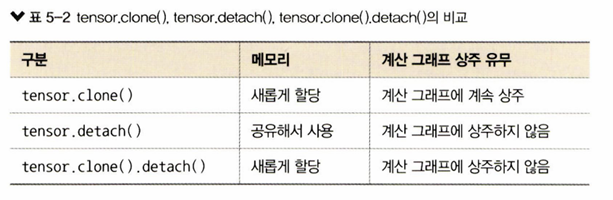

**계산 그래프**
: 계산과정을 그래프로 나타낸 것
* 사용하는 이유
1. 국소적 계산 가능
2. 역전파를 통한 미분 계산이 편리
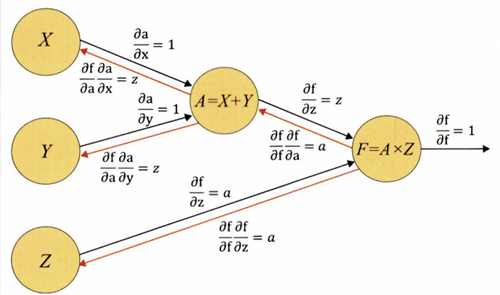

**연쇄 법칙**
: 두 개 이상의 함수가 결합된 함수, 즉 합성 함수의 미분법을 연쇄 법칙 혹은 체인룰
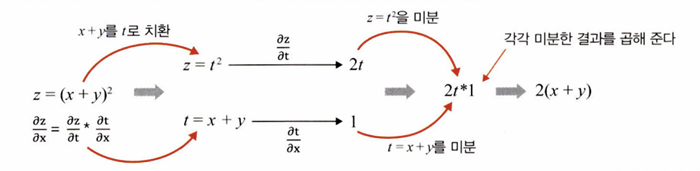

2. clip(): 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용

In [46]:
import numpy as np
exam = np.array([-1.8, -1.2, -0.7, 0.0, 0.8, 1.4, 1.9])
print(exam)
print(np.clip(exam, -0.5, -0.5))

[-1.8 -1.2 -0.7  0.   0.8  1.4  1.9]
[-0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]


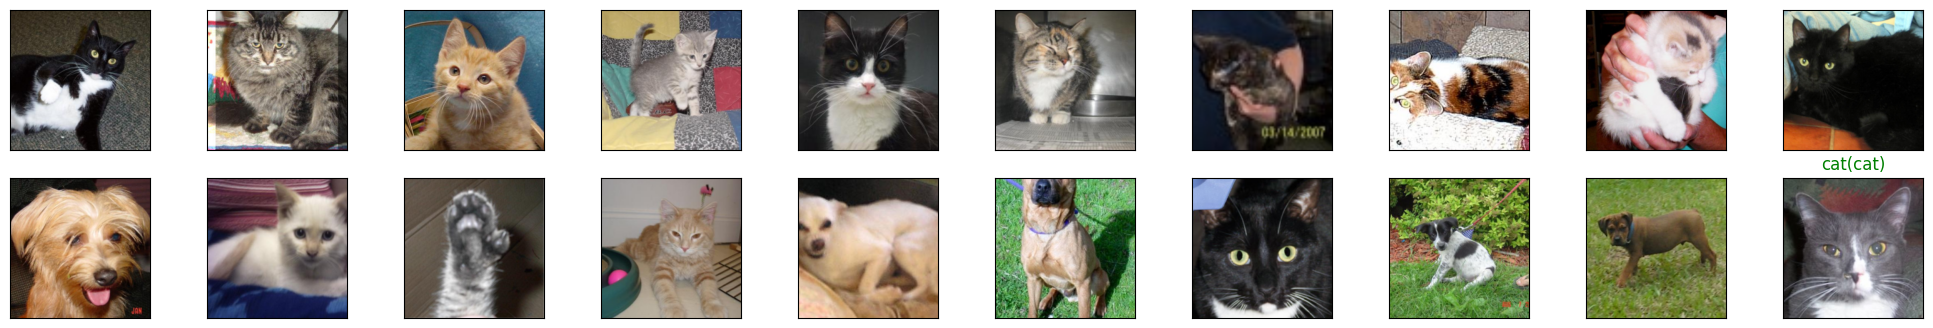

<Figure size 640x480 with 0 Axes>

In [49]:
classes = {0:'cat', 1:'dog'}

dataiter = iter(test_loader)
images, labels = next(dataiter)
output = model(images)
_, preds = torch.max(output,1)

fig = plt.figure(figsize = (25,4))
for idx in np.arange(20):
  ax = fig.add_subplot(2,10, idx+1, xticks=[], yticks=[])
  plt.imshow(im_convert(images[idx]))
  a.set_title(classes[labels[i].item()])

ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
             color = ("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

1. add_subplot: 한 화면에 여러 개의 이미지를 담기 위해 사용
* 첫번째 파라미터: 행의 수 의미. 이미지를 두 줄로 출력
* 두번째 파라미터: 열의 수 의미, 한줄에 열개의 이미지 출력
* 세번째 파라미터: 인덱스를 의미, 행과 열 기준으로 순차적으로 이미지를 출력
* 네 번째 파라미터: 틱을 삭제하겠다는 의미
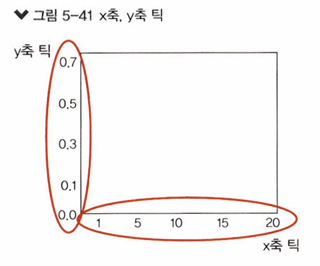

2. classes[preds[idx].item()] : preds[idx].item() 값이 classes로 정의된 '0'과 '1' 중 어떤 값을 갖는지 판별하겠다는 의미

3. Figure 안에서 subplot의 위치를 조정할 때 사용. hspace와 wspace를 사용해서 서브플롯 간의 간격을 조정할 수 있음
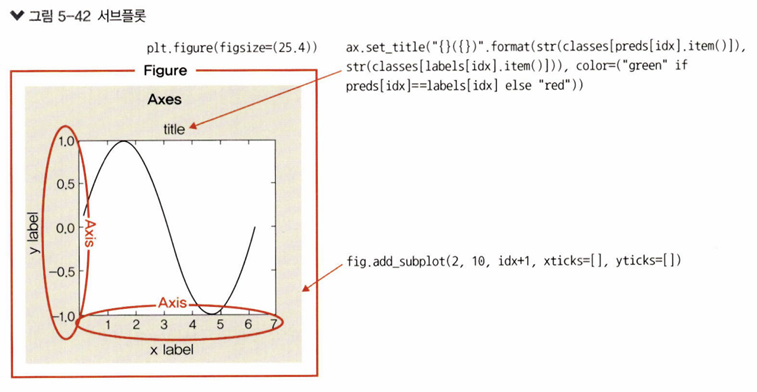

# **5.4 설명 가능한 CNN**
**5.4.1 특성 맵 시각화**
* 특성 맵(feature map) : 입력 이미지 또는 다른 특성 맵처럼 필터를 입력에 적용한 결과
* PIL(Python Image Library): 이미지 분석 및 처리를 쉽게 할 수 있도록 도와주는 라이브러리

In [50]:
!pip install pillow

In [52]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [71]:
class XAI(torch.nn.Module):
  def __init__(self, num_classes =2):
    super(XAI, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, bias = False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Conv2d(64,64,kernel_size = 3, padding=1, bias = False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size =2, stride = 2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1,bias = False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(128,128,kernel_size = 3, padding=1, bias = False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size =2, stride = 2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256,256,kernel_size = 3, padding=1, bias = False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace = True),
        nn.Dropout(0.4),
        nn.Conv2d(256,256,kernel_size = 3, padding=1, bias = False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size =2, stride = 2),

        nn.Conv2d(256, 512, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512,512,kernel_size = 3, padding=1, bias = False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace = True),
        nn.Dropout(0.4),
        nn.Conv2d(512,512,kernel_size = 3, padding=1, bias = False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size =2, stride = 2),

        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512,512,kernel_size = 3, padding=1, bias = False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace = True),
        nn.Dropout(0.4),
        nn.Conv2d(512,512,kernel_size = 3, padding=1, bias = False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size =2, stride = 2),
    )
    self.classifier = nn.Sequential(
        nn.Linear(512,512, bias = False),
        nn.Dropout(0.5),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace = True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

  def forward(self,x):
    x = self.features(x)
    x = x.view(-1, 512)
    x = self.classifier(x)
    return F.log_softmax(x)


1. log_softmax()는 신경망 말단의 결괏갑들을 확률 개념으로 해석하기 위해 소프트맥스 함수의 결과에 log 값을 취한 연산
* 소프트맥스를 사용하지 않고 로그 소프트맥스를 사용하는 이유는 소프트맥스는 기울기 소멸 문제에 취약하기 때문
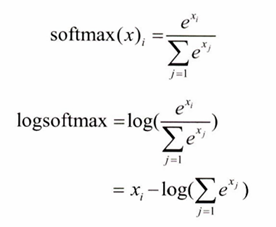

In [72]:
model = XAI()
model.to(device)
model.eval()

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

In [73]:
class LayerActivations:
  features = []
  def __init__(self, model, layer_num):
    self.hook =  model[layer_num].register_forward_hook(self.hook_fn)

  def hook_fn(self, module, input, output):
    self.features = output.detach().numpy()

  def remove(self):
    self.hook.remove()

1. 파이토치는 매 계층마다 print문을 사용하지 않더라고 hook 기능을 사용해 각 계층의 활성화 함수 및 기울기 값 확인할 수 있음
* 따라서 register_forward_hook 의 목적은 순전파 중에 각 네트워크 모듈의 입력 및 출력을 가져오는 것

In [74]:
import torch
x = torch.Tensor([0,1,2,3]).requires_grad_()
y = torch.Tensor([4,5,6,7]).requires_grad_()
w = torch.Tensor([1,2,3,4]).requires_grad_()
z = x+y;
o = w.matmul(z)
o.backward()
print(x.grad, y.grad, z.grad, w.grad, o.grad)

tensor([1., 2., 3., 4.]) tensor([1., 2., 3., 4.]) None tensor([ 4.,  6.,  8., 10.]) None


/tmp/ipykernel_6754/3402858245.py:8: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  print(x.grad, y.grad, z.grad, w.grad, o.grad)


torch.Size([1, 3, 100, 100])


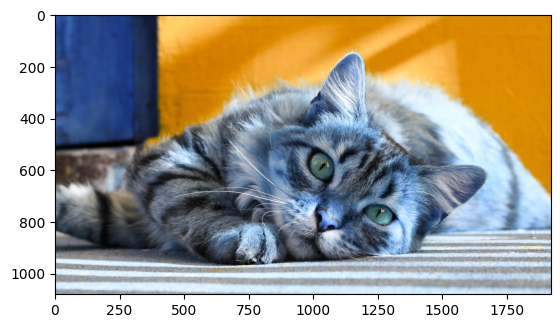

In [75]:
#이미지 호출
img = cv2.imread('080289/chap05/data/cat.jpg')
plt.imshow(img)
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0)
print(img.shape)

1. cv2.resize : 이미지 크기를 변경할 때 사용함
** 파라미터**
* 첫번째 파라미터: 변경할 이미지 파일
* 두번째 파라미터: 변경될 이미지 크기를 (너비, 높이)로 지정
* interpolation: 보간법

: 이미지 크기를 변경할 경우 변형된 이미지의 픽셀을 추정해서 값을 할당해야함. 이미지 비율을 변경하면 존재하지 않는 영역에서 새로운 픽셀 값을 매핑하거나 존재하는 픽셀들을 압축해서 새로운 값을 할당해야함.-> 이러한 상황을 피하고자 이미지상에 존재하는 픽셀 데이터(x,y)들에 대해 근사 함수 f(x,y)를 적용해서 새로운 픽셀 값을 구하는 것이 보간법

2. ToTensor()(img).unsqueeze(0)에서 unsqueeze():1차원 데이터를 생성하는 함수 -> 이미지를 텐서로 변환, 그 변환된 데이터를 1차원으로 변경

In [76]:
import torch

x1 = torch.rand(3,10,64)
x2 = x1.unsqueeze(dim = 0)
print(x2.shape)
print('----------')
x3 = x1.unsqueeze(dim =1)
print(x3.shape)

torch.Size([1, 3, 10, 64])
----------
torch.Size([3, 1, 10, 64])


In [77]:
#conv2d.특성 맵 확인
result = LayerActivations(model.features, 0)

model(img)
activations = result.features


/tmp/ipykernel_6754/3921435771.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


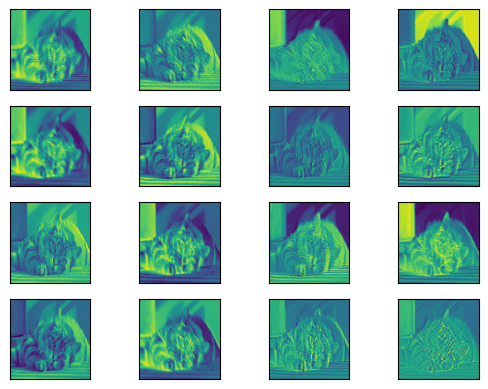

<Figure size 1200x800 with 0 Axes>

In [78]:
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left = 0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [79]:
result = LayerActivations(model.features, 20)

model(img)
activations = result.features

/tmp/ipykernel_6754/3921435771.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


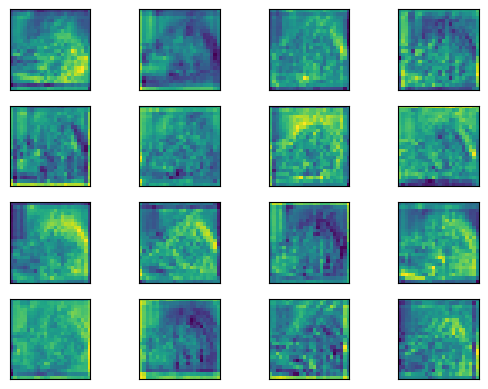

<Figure size 1200x800 with 0 Axes>

In [80]:
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left = 0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [81]:
result = LayerActivations(model.features, 40)

model(img)
activations = result.features

/tmp/ipykernel_6754/3921435771.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


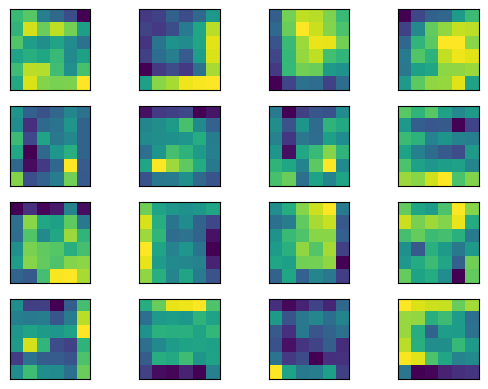

<Figure size 1200x800 with 0 Axes>

In [82]:
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left = 0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()